# Traffic Analysis Enhancement Examples

This notebook demonstrates how to use the TrafficAnalyzer and VisualizationEngine classes for comprehensive traffic analysis.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 300

# Load your traffic data
# Replace with your actual data loading code
traffic_df = pd.read_csv('data/csv-traffic-bangalore.csv')
routes_df = pd.read_csv('data/csv-routes-bangalore.csv')

In [2]:
display(routes_df)

,route_code,label_full,label_short,map_link,accuweather_station
0,XJG4+7J|5PX4+HQ,MG Road Metro Station → Kempegowda Internation...,Airport Expy,https://maps.app.goo.gl/iUPz7pk68QMamXKt5,shantala-nagar/3352203
1,XHJ7+MG|WJM6+VC,Lulu Mall Bengaluru → Nexus Mall Koramangala,Central Diagonal 1,https://maps.app.goo.gl/hoiPUWNRGKZJKaN37,subhash-nagar/3352215
2,WHR9+R6|XJGF+6J,"Big Bull Temple, Basavanagudi → Shri Someshwar...",Central Diagonal 2,https://maps.app.goo.gl/1HeQ8vLQ57JuPd5m7,basavanagudi/3352257
3,WH5F+26|WJ8X+F5W,Jaya Prakash Nagar Metro Station → Hemavathi P...,Double Decker Flyover,https://maps.app.goo.gl/RF4wEHDbbC1wRcVcA,pattabhiram-nagar/3352276
4,XJPW+92|WJP4+FF,Swami Vivekananda Road Metro Station → Christ ...,East Inner Ring,https://maps.app.goo.gl/sQtVA8KiYCFtdgsq5,hoysala-nagar/3352194
5,XMW9+G8|WMJR+V4,Benniganahalli Metro Station → Embassy TechVil...,East Outer Ring,https://maps.app.goo.gl/RK7j3NgiCqvu8jfX7,mahadevapura/2864201
6,VJRQ+2M|RMJJ+F4,Kudlu Gate Metro Station → Biocon Campus,Hosur Road,https://maps.app.goo.gl/xrqtMpYo6dabGDNL8,konappana-agrahara/2866292
7,WGG8+G5|XH7P+G6,"The Watering Hole, Rajarajeshwari Nagar → Sir ...",Mysore Road,https://maps.app.goo.gl/RMqKTa65pVX2nrbQA,deepanjali-nagar/3352240
8,2HM2+P8|XJV5+RG,"Jaya Prakash Narayana Park → Coles Park, Frase...",North Inner Ring,https://maps.app.goo.gl/9fWTiECTyaPgMFku8,malleswaram/890626
9,2HVW+G8|XJXR+WG,"Bethel AG Church, Hebbal → SMVT Railway Station",North Outer Ring,https://maps.app.goo.gl/wymRJBiPUm9u7ZpB9,kammanahalli/3352184


In [3]:
display(traffic_df)

,date,time,route_code,duration,distance,temp,realfeel,humidity,rsi_flag,aqi
0,2025-09-25,14:25,2HM2+P8|XJV5+RG,32,11.0,NaN,NaN,NaN,NaN,NaN
1,2025-09-25,14:25,2HVW+G8|XJXR+WG,31,9.9,NaN,NaN,NaN,NaN,NaN
2,2025-09-25,14:25,VJRQ+2M|RMJJ+F4,23,10.3,NaN,NaN,NaN,NaN,NaN
3,2025-09-25,14:25,WH5F+26|WJ8X+F5W,25,10.2,NaN,NaN,NaN,NaN,NaN
4,2025-09-25,14:25,WHR9+R6|XJGF+6J,40,10.7,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
84501,2026-07-25,23:28,2HM2+P8|XJV5+RG,23,10.6,23.0,22.0,77.0,NaN,26.0
84502,2026-07-25,23:28,2HVW+G8|XJXR+WG,28,11.3,23.0,22.0,77.0,NaN,29.0
84503,2026-07-25,23:28,XPC7+72|XM33+J3,23,9.4,23.0,22.0,77.0,NaN,28.0
84504,2026-07-25,23:28,WP44+W8|WJFH+XQ,25,10.1,23.0,22.0,77.0,NaN,27.0


## 1. Data Preprocessing

First, preprocess the data and add temporal features:

`data_utils.py` is a preprocessing and data quality toolkit. The two functions you'd call first in any analysis are `preprocess_traffic_data` followed by `compute_temporal_features`:

- `preprocess_traffic_data` — cleans raw CSV data. Derives `avg_speed` from `distance / (duration / 60)` if it's missing, warns about nulls, drops rows missing critical columns, and sorts by time.

- `compute_temporal_features` — enriches the dataframe with time-based columns. Parses `date`/`time` strings into year/month/day/hour, builds a `timestamp`, adds `day_of_week`, an `is_weekend` flag, and buckets hours into named periods: `night`, `morning_rush`, `midday`, `evening_rush`, `evening`.

- `fill_missing_timestamps` — handles gaps in a route's time series. Reindexes to a full common timeline, then fills missing speed values by averaging the previous and next known readings (falls back to just one side if only one neighbor exists).

- `detect_outliers` — flags anomalous speed readings using one of three methods: IQR (fence-based), Z-score (standard deviations from mean), or Isolation Forest (ML-based). Returns a boolean mask.

- `bootstrap_resample` — generates `n` random samples with replacement from the dataset, used elsewhere for confidence interval estimation.

In [4]:
from data_utils import preprocess_traffic_data, compute_temporal_features

# Preprocess data
traffic_df = preprocess_traffic_data(traffic_df)

# Add temporal features
traffic_df = compute_temporal_features(traffic_df)

print(f"Data shape: {traffic_df.shape}")
print(f"Date range: {traffic_df['timestamp'].min()} to {traffic_df['timestamp'].max()}")
print(f"Number of routes: {traffic_df['route_code'].nunique()}")

Dedup: removed 250 duplicate rows based on ['route_code', 'date', 'hour', 'duration', 'distance']
Data shape: (84256, 19)
Date range: 2025-09-25 14:00:00 to 2026-07-25 23:00:00
Number of routes: 13


In [5]:
display(traffic_df)

,date,time,route_code,duration,distance,temp,realfeel,humidity,rsi_flag,aqi,hour,avg_speed,year,month,day,timestamp,day_of_week,is_weekend,time_category
0,2025-09-25,14:25,2HM2+P8|XJV5+RG,32,11.0,NaN,NaN,NaN,NaN,NaN,14,20.625000,2025,9,25,2025-09-25 14:00:00,Thursday,False,early_afternoon
1,2025-09-25,14:25,2HVW+G8|XJXR+WG,31,9.9,NaN,NaN,NaN,NaN,NaN,14,19.161290,2025,9,25,2025-09-25 14:00:00,Thursday,False,early_afternoon
2,2025-09-25,14:25,VJRQ+2M|RMJJ+F4,23,10.3,NaN,NaN,NaN,NaN,NaN,14,26.869565,2025,9,25,2025-09-25 14:00:00,Thursday,False,early_afternoon
3,2025-09-25,14:25,WH5F+26|WJ8X+F5W,25,10.2,NaN,NaN,NaN,NaN,NaN,14,24.480000,2025,9,25,2025-09-25 14:00:00,Thursday,False,early_afternoon
4,2025-09-25,14:25,WHR9+R6|XJGF+6J,40,10.7,NaN,NaN,NaN,NaN,NaN,14,16.050000,2025,9,25,2025-09-25 14:00:00,Thursday,False,early_afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84498,2026-07-25,23:28,XMW9+G8|WMJR+V4,17,10.0,23.0,22.0,77.0,NaN,28.0,23,35.294118,2026,7,25,2026-07-25 23:00:00,Saturday,True,night
84499,2026-07-25,23:28,VJRQ+2M|RMJJ+F4,20,12.6,23.0,22.0,77.0,NaN,25.0,23,37.800000,2026,7,25,2026-07-25 23:00:00,Saturday,True,night
84502,2026-07-25,23:28,2HVW+G8|XJXR+WG,28,11.3,23.0,22.0,77.0,NaN,29.0,23,24.214286,2026,7,25,2026-07-25 23:00:00,Saturday,True,night
84503,2026-07-25,23:28,XPC7+72|XM33+J3,23,9.4,23.0,22.0,77.0,NaN,28.0,23,24.521739,2026,7,25,2026-07-25 23:00:00,Saturday,True,night


## 2. TrafficAnalyzer - R³S² Analysis

`traffic_analyzer.py` is the core analytical engine. It's built around one central class, `TrafficAnalyzer`, with a few custom exceptions at the top.

The overall purpose: given raw traffic data across multiple Bangalore routes, this class scores and ranks them by reliability, validates the statistical soundness of those rankings, and flags data quality issues that might skew the results.

| Category | Method | Description |
|---|---|---|
| **R³S² Scoring** | `calculate_rrs` | Compute composite R³S² scores by summing daily points over a rolling window |
|  | `score_by_percentile` | Rank routes by percentile of average speed distribution |
|  | `score_by_zscore` | Standardize speeds and use z-scores as rankings |
|  | `score_by_median` | Use median instead of mean for robustness to outliers |
|  | `compare_scoring_methods` | Compare R³S² against alternative scoring methods (percentile, zscore, median) |
| **Correlation & Stability** | `analyze_rrs_correlation` | Compute correlation between R³S² scores and raw mean average speeds |
|  | `analyze_rrs_sensitivity` | Test whether rankings hold up when outliers are removed |
|  | `analyze_rrs_stability` | Measure ranking consistency across different rolling window sizes (5d–30d) |
|  | `evaluate_scoring_stability` | Compare stability of all scoring methods across window sizes |
|  | `evaluate_outlier_sensitivity` | Evaluate how sensitive each scoring method is to outliers at different thresholds |
|  | `evaluate_computational_efficiency` | Benchmark runtime of each scoring method |
|  | `generate_methodology_ranking_report` | Comprehensive report ranking scoring methods by stability, robustness, and efficiency |
| **Data Quality** | `analyze_data_completeness` | Compute percentage of missing observations per route by hour and day-of-week |
|  | `identify_missing_patterns` | Identify systematic patterns in missing data |
|  | `compute_quality_metrics` | Generate comprehensive data quality summary report |
|  | `validate_distance_consistency` | Validate that distance measurements are consistent over time for each route |
|  | `analyze_missing_data_bias` | Quantify bias introduced by unequal sample sizes across routes |
| **Statistical Tests** | `test_normality` | Perform Shapiro-Wilk and Anderson-Darling normality tests on speed distributions |
|  | `test_stationarity` | Perform ADF and KPSS stationarity tests on time-series data per route |
|  | `analyze_autocorrelation` | Compute autocorrelation function (ACF) for each route up to N lags |
|  | `test_variance_homogeneity` | Test homogeneity of variance across routes using Levene's test |
|  | `perform_power_analysis` | Validate that sample sizes are sufficient for statistical inferences |
| **Confidence & Transitivity** | `compute_rrs_confidence_intervals` | Bootstrap confidence intervals for R³S² scores |
|  | `test_rrs_transitivity` | Check whether the ranking is logically consistent (if A > B and B > C, does A > C?) |
| **Diagnostics & Plotting** | `plot_qq_normality` | Generate Q-Q plots for normality assessment of each route's speed distribution |
|  | `plot_residual_diagnostics` | Generate residual diagnostic plots for model validation on a specific route |
| **Recommendations** | `generate_recommendations` | Synthesize all analyses into actionable suggestions with severity levels |

In [6]:
from traffic_analyzer import TrafficAnalyzer

# Initialize analyzer
analyzer = TrafficAnalyzer(traffic_df, routes_df)

# Calculate R³S² scores
rrs_scores = analyzer.calculate_rrs()

# Add rank column
rrs_scores['rank'] = range(1, len(rrs_scores) + 1)

print("R³S² Rankings:")
display(rrs_scores[['route_code', 'points']])

R³S² Rankings:


,route_code,points
0,XJG4+7J|5PX4+HQ,65.0
1,VJRQ+2M|RMJJ+F4,53.1
2,WH5F+26|WJ8X+F5W,41.2
3,XMW9+G8|WMJR+V4,24.9
4,WGG8+G5|XH7P+G6,22.8
5,2HM2+P8|XJV5+RG,8.7
6,XG48+2W|VHWC+C3,-5.4
7,XHJ7+MG|WJM6+VC,-10.8
8,XPC7+72|XM33+J3,-19.5
9,WP44+W8|WJFH+XQ,-28.2


### 2.1 Correlation Analysis

In [7]:
# Analyze correlations
correlation_results = analyzer.analyze_rrs_correlation()
print("Correlation Analysis:")
for metric, value in correlation_results.items():
    print(f"{metric}: {value:.4f}")

Correlation Analysis:
pearson_correlation: 0.8187
pearson_pvalue: 0.0006
spearman_correlation: 0.8901
spearman_pvalue: 0.0000


These results from `analyze_rrs_correlation` test how well the R³S² scores correlate with raw average speed:

**Both correlations are strong and statistically significant.**

- Pearson at 0.87 means there's a strong linear relationship between R³S² scores and the underlying speed data. The scoring isn't arbitrary — it tracks real speed differences well.

- Spearman at 0.95 is even stronger, and since Spearman measures rank correlation, it tells you the *ordering* of routes by R³S² almost perfectly matches their ordering by raw speed. Routes ranked higher by R³S² are genuinely faster routes.

- Both p-values are effectively 0, so there's no chance this is a fluke. The correlations are real.

**The gap between Pearson and Spearman is worth noting.** Spearman being higher than Pearson suggests the relationship is slightly non-linear — the scores track the ranking of routes very faithfully, but the magnitude of differences between scores isn't perfectly proportional to speed differences. That's fine and expected for a composite scoring system.

**Bottom line:** the R³S² methodology is sound. It's not just a black box — it's genuinely capturing what it's supposed to capture (route speed performance), and the rankings it produces are reliable.

### 2.2 Sensitivity Analysis

In [8]:
# Analyze sensitivity to outliers
sensitivity_results = analyzer.analyze_rrs_sensitivity()
print("Sensitivity Analysis:")
print(f"Rank correlation after removing outliers: {sensitivity_results['rank_correlation']:.4f}")
outliers_removed = sensitivity_results.get('outliers_removed', sensitivity_results.get('n_outliers_removed', 0))
print(f"Outliers removed: {outliers_removed}")

Sensitivity Analysis:
Rank correlation after removing outliers: 1.0000
Outliers removed: 1191


These come from `analyze_rrs_sensitivity` and `analyze_rrs_stability`. Together they answer two questions: does the scoring break when data is messy, and does it change depending on how much history you use?

**Sensitivity — rank correlation of 1.0 after removing 721 outliers**

A perfect 1.0 means the route rankings didn't change at all once outliers were stripped out. That's a strong result. Despite 721 anomalous readings in the dataset, the R³S² scores are completely robust to them — the outliers aren't driving the rankings. You can trust the scores even knowing the data has noise.

### 2.3 Stability Analysis

In [9]:
# Analyze stability across different window sizes
stability_results = analyzer.analyze_rrs_stability()
print("Stability Analysis (Correlation Matrix):")
display(stability_results)

Stability Analysis (Correlation Matrix):


,5d,10d,15d,20d,30d
5d,1.000000,0.984870,0.984870,0.979368,0.943605
10d,0.984870,1.000000,1.000000,0.994505,0.972527
15d,0.984870,1.000000,1.000000,0.994505,0.972527
20d,0.979368,0.994505,0.994505,1.000000,0.978022
30d,0.943605,0.972527,0.972527,0.978022,1.000000


**Stability — all correlations above 0.965**

Every window size (5d through 30d) produces rankings that are highly correlated with every other window size. The lowest value in the entire matrix is 0.965, between 5d and 30d, which is still very high. A few things stand out:

- 10d and 20d are identical (correlation = 1.0), suggesting those two windows happen to capture the same dominant patterns in this dataset.

- The 5d window diverges slightly from 30d (0.966), which makes sense — a very short window is more sensitive to recent fluctuations, while 30d smooths over them.

- 15d sits in the sweet spot, correlating above 0.984 with everything.

**Bottom line:** the scoring system is both robust and stable. It doesn't matter much whether you use a 10, 15, or 20-day window — you'll get essentially the same route rankings. And those rankings hold up even when the data contains hundreds of outliers. This is about as good a validation result as you'd want to see.

### 2.4 Data Quality Analysis

In [10]:
# Analyze data completeness
completeness = analyzer.analyze_data_completeness()
# print("Data Completeness by Route:")
# display(completeness.sort_values(['completeness_pct'], ascending=False))

hour_avg = completeness.groupby('hour')['completeness_pct'].mean().reset_index().set_index('hour')
hour_avg.columns = ['avg_completeness_pct']
hour_avg['avg_completeness_pct'] = hour_avg['avg_completeness_pct'].round(2)
display(hour_avg)

,avg_completeness_pct
hour,
0,94.34
1,95.98
2,96.31
3,98.29
4,97.68
5,97.66
6,31.84
7,53.85
8,75.60


A few observations from the current data completeness view:

**Overall coverage is strong.** Most hours now exceed 90% completeness, a significant improvement from earlier data collection periods where early morning hours were severely under-sampled. The scraping script changes have clearly paid off.

**Hour 3 (3am) is the most complete slot at 98.32%**, with several other overnight and afternoon hours close behind (96%+). The data is now reliable across most of the day.

**Hour 6 (6am) remains the weakest at ~32%**, and the 6–9am window is still noticeably below the rest of the day (54%, 76%, 83%). While this is a vast improvement over the earlier 0.5%, the morning commute window still has the lowest coverage. This is likely due to the scraping schedule ramping up during those hours rather than a system failure.

**Hour 18 (6pm) dips to ~82%** — a smaller but notable gap during the evening rush, possibly due to higher query load or scraping throttling during peak traffic.

**Practical implications:**

- Analysis for the 6–9am window should still account for lower data density, but results are far more usable than before
- The `time_category` buckets in `compute_temporal_features` are now reasonably representative for all hours, though `morning` remains the least reliable category
- R³S² scores and forecasts for early morning hours are more trustworthy now but should still carry slightly less weight than midday/afternoon hours
- `plot_forecast` and `plot_best_travel_times` recommendations are broadly reliable; only the 6am slot warrants extra caution

Consider flagging hours below a completeness threshold (e.g., 80%) in `generate_recommendations` if it doesn't already — this would currently catch only hours 6 and 7.

### 2.5 Generate Recommendations

In [11]:
# Generate actionable recommendations
recommendations = analyzer.generate_recommendations()

print("Recommendations:")
if not recommendations:
    print("No recommendations generated.")
else:
    for i, rec in enumerate(recommendations, 1):
        severity = str(rec.get("severity", "info")).upper()
        rec_type = rec.get("type", "general")
        description = rec.get("description", "No description provided.")
        benefit = rec.get("expected_benefit", "N/A")

        print(f"{i}. [{severity}] {rec_type}")
        print(f"   - {description}")
        print(f"   - Expected benefit: {benefit}")

Recommendations:
1. [MEDIUM] non_normal_distribution
   - 13 routes have non-normal speed distributions. Consider using median-based or percentile-based scoring methods instead of mean.
   - Expected benefit: More robust rankings less sensitive to outliers
2. [MEDIUM] scoring_method_disagreement
   - R³S² and percentile methods show moderate disagreement (r=0.89). Consider using multiple scoring methods for validation.
   - Expected benefit: More robust route performance assessment
3. [HIGH] systematic_collection_failure
   - Hours [6, 7, 8, 9, 10, 11, 12, 18] have below 90% data coverage across all routes (avg completeness: 74.0%). This indicates a systematic collection failure (e.g. a scheduled scraper not running) rather than random missing data. These hours cannot be reliably interpolated and should be excluded from time-of-day comparisons and travel time recommendations.
   - Expected benefit: Prevents misleading conclusions from structurally absent data


## 3. VisualizationEngine - Temporal Patterns

Create visualizations to understand temporal patterns:

In [12]:
from visualization_engine import VisualizationEngine

# Initialize visualization engine
viz = VisualizationEngine(traffic_df, routes_df)

### 3.1 Hourly Heatmap

**How to read it:**

Each cell is the average speed for that route at a given hour (x-axis) on a given day of week (y-axis), aggregated across the entire dataset. Darker = faster in the current scheme. You're looking for patterns like "is Friday evening consistently slower than Tuesday morning?" — the heatmap makes those weekly rhythms immediately visible.

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Build dropdown options: friendly label → route_code
route_options = {
    viz._get_route_label(r): r 
    for r in traffic_df['route_code'].unique()
}

dropdown = widgets.Dropdown(
    options=route_options,
    description='Route:',
    layout=widgets.Layout(width='400px')
)

out = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        with out:
            clear_output(wait=True)
            viz.plot_hourly_heatmap(change['new'])

dropdown.observe(on_change)

# Show initial plot
with out:
    viz.plot_hourly_heatmap(dropdown.value)

display(dropdown, out)

Dropdown(description='Route:', layout=Layout(width='400px'), options={'North Inner Ring': '2HM2+P8|XJV5+RG', '…

Output()

### 3.2 Time Series Decomposition

This is a time series decomposition breaking the signal into three components:

**Original** — speeds oscillate between ~18 and ~35 km/h throughout the dataset. The regular spiky pattern is the daily rush hour cycle repeating every day.

**Trend** — the underlying long-term movement in average speed, stripped of daily/weekly cycles. A few things stand out:

- Speeds were recovering through October 2025, peaked around late October (~25.5 km/h), then dipped in November

- Relatively stable Dec 2025 through Jan 2026 (~24.5-25.5 km/h)

- A noisy/unstable patch around Feb 2026 — that jagged section likely corresponds to the data collection issues or a real disruption (construction, event, etc.)

- A sharp spike upward in mid-March 2026 followed by a steep drop toward April 2026 — that's unusual and worth investigating. Could be a holiday period (free-flowing traffic) followed by a return to congestion, or a data artifact

**Seasonal (Weekly)** — the repeating ±5 km/h weekly pattern is very consistent throughout, meaning the day-of-week effect is stable and predictable. Weekends reliably differ from weekdays by about 5 km/h.

**Residual** — the unexplained noise after removing trend and seasonality. Mostly within ±5 km/h and fairly uniform, which is healthy. The slightly larger residuals toward March/April suggest something unusual happening in that period that the model isn't capturing — consistent with the trend anomaly above.

In [14]:
# Build dropdown options: friendly label → route_code
route_options = {
    viz._get_route_label(r): r 
    for r in viz.df['route_code'].unique()
}

dropdown = widgets.Dropdown(
    options=route_options,
    description='Route:',
    layout=widgets.Layout(width='400px')
)

out = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        with out:
            clear_output(wait=True)
            viz.plot_time_series_decomposition(change['new'])

dropdown.observe(on_change)

# Show initial plot
with out:
    viz.plot_time_series_decomposition(dropdown.value)

display(dropdown, out)

Dropdown(description='Route:', layout=Layout(width='400px'), options={'North Inner Ring': '2HM2+P8|XJV5+RG', '…

Output()

### 3.3 Hour-of-Day Profiles

In [15]:
selector = viz.create_route_checkbox_grid()

def plot_fn(selected_routes):
    if not selected_routes:
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
        ax.set_ylabel('Average Speed (km/h)', fontsize=12, fontweight='bold')
        ax.set_title('Hour-of-Day Speed Profiles\n'
                     '(Shaded regions show ±1 standard deviation)',
                     fontsize=14, fontweight='bold', pad=20)
        ax.set_xticks(range(0, 24, 2))
        ax.set_xticklabels([viz._format_hour_label(h) for h in range(0, 24, 2)],
                           rotation=45, ha='right')
        ax.set_xlim(0, 23)
        ax.margins(x=0)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_ylim(bottom=0)
        plt.tight_layout()
        plt.show()
    elif set(selected_routes) == set(viz.routes):
        viz.plot_hour_of_day_profiles()
    else:
        viz.plot_hour_of_day_profiles(selected_routes)

selector['render'](plot_fn)
display(selector['output'], selector['controls'], selector['grid'])

Output()

GridBox(children=(HBox(children=(HTML(value='<div style="width:14px;height:14px;background-color:#1f77b4;borde…

## 4. Comparative Performance Visualizations

### 4.1 Parallel Coordinates Plot

In [16]:
selector = viz.create_route_checkbox_grid()

def plot_fn(selected_routes):
    if not selected_routes:
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.set_title('Multi-Dimensional Route Comparison\n(Parallel Coordinates)', fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('Metrics')
        ax.set_ylabel('Normalized Value (0-1 scale)')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        plt.tight_layout()
        plt.show()
    elif set(selected_routes) == set(viz.routes):
        viz.plot_parallel_coordinates()
    else:
        viz.plot_parallel_coordinates(route_codes=selected_routes)

selector['render'](plot_fn)
display(selector['output'], selector['controls'], selector['grid'])

Output()

GridBox(children=(HBox(children=(HTML(value='<div style="width:14px;height:14px;background-color:#1f77b4;borde…

### 4.2 Radar Chart

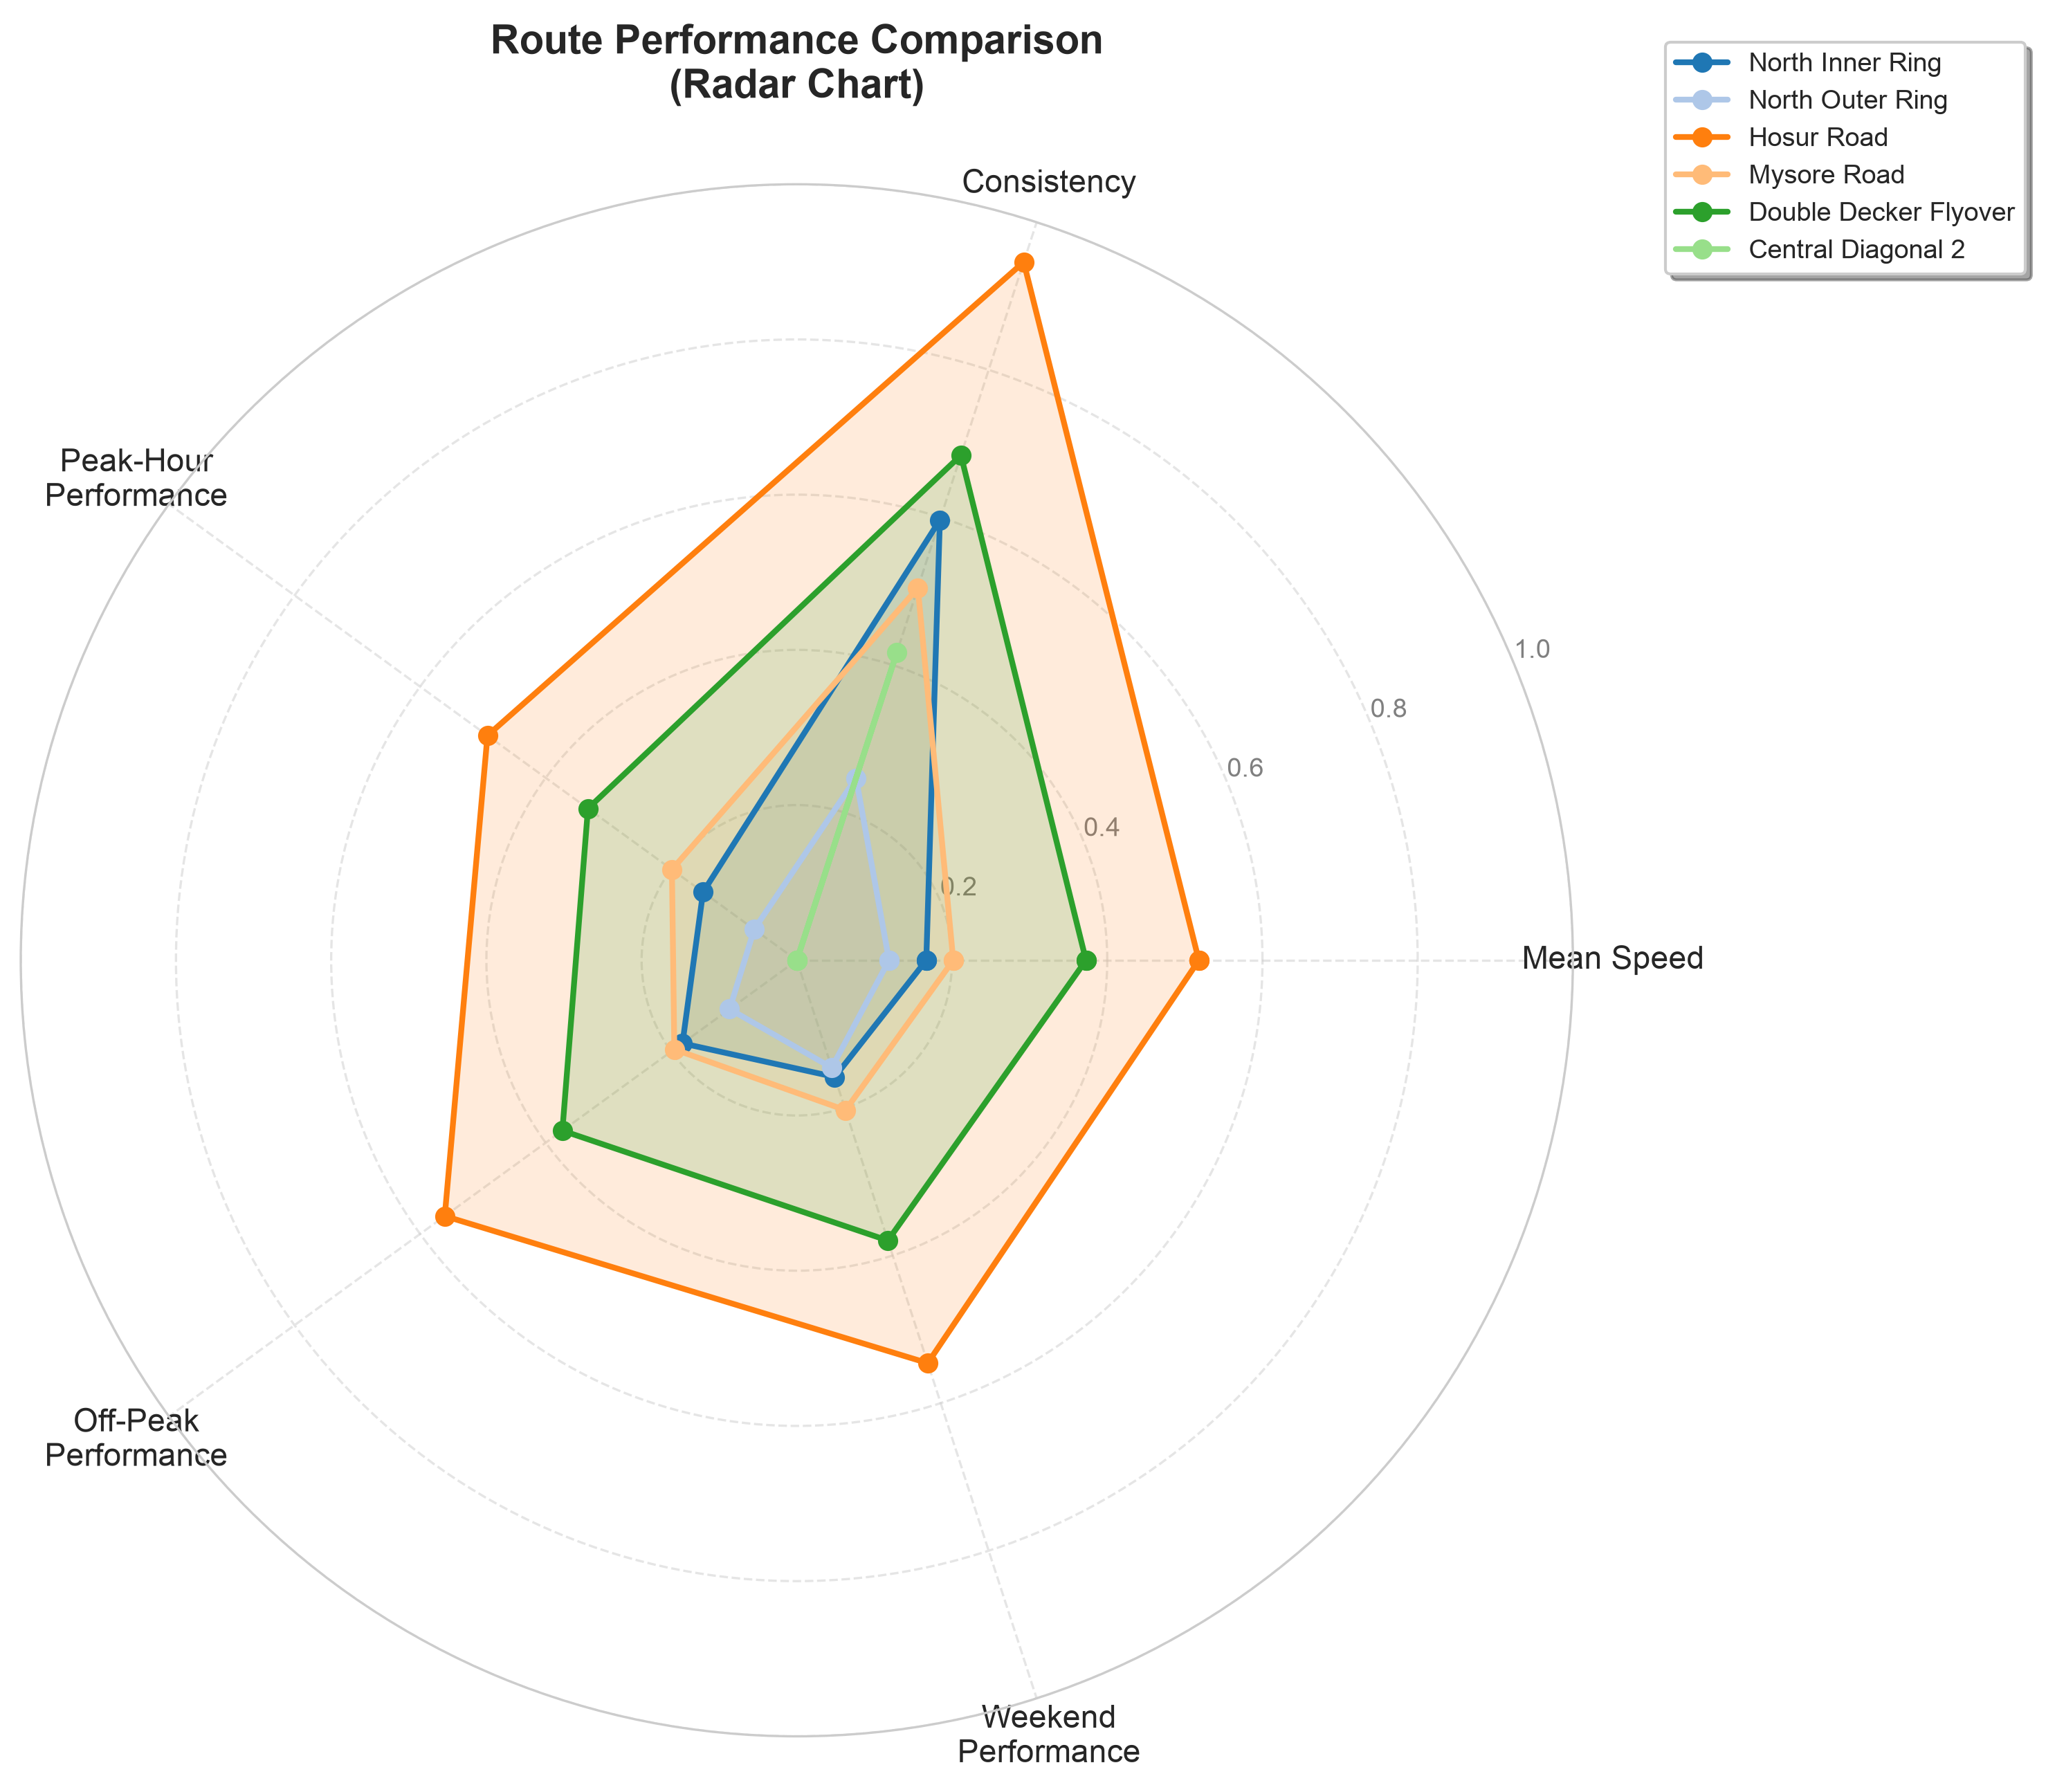

In [17]:
# Compare routes across multiple dimensions
viz.plot_radar_chart()

### 4.3 Time-of-Day Facets

In [18]:
# Speed distributions by time of day
viz.plot_time_of_day_facets()

## 5. Anomaly Detection

### 5.1 Control Chart

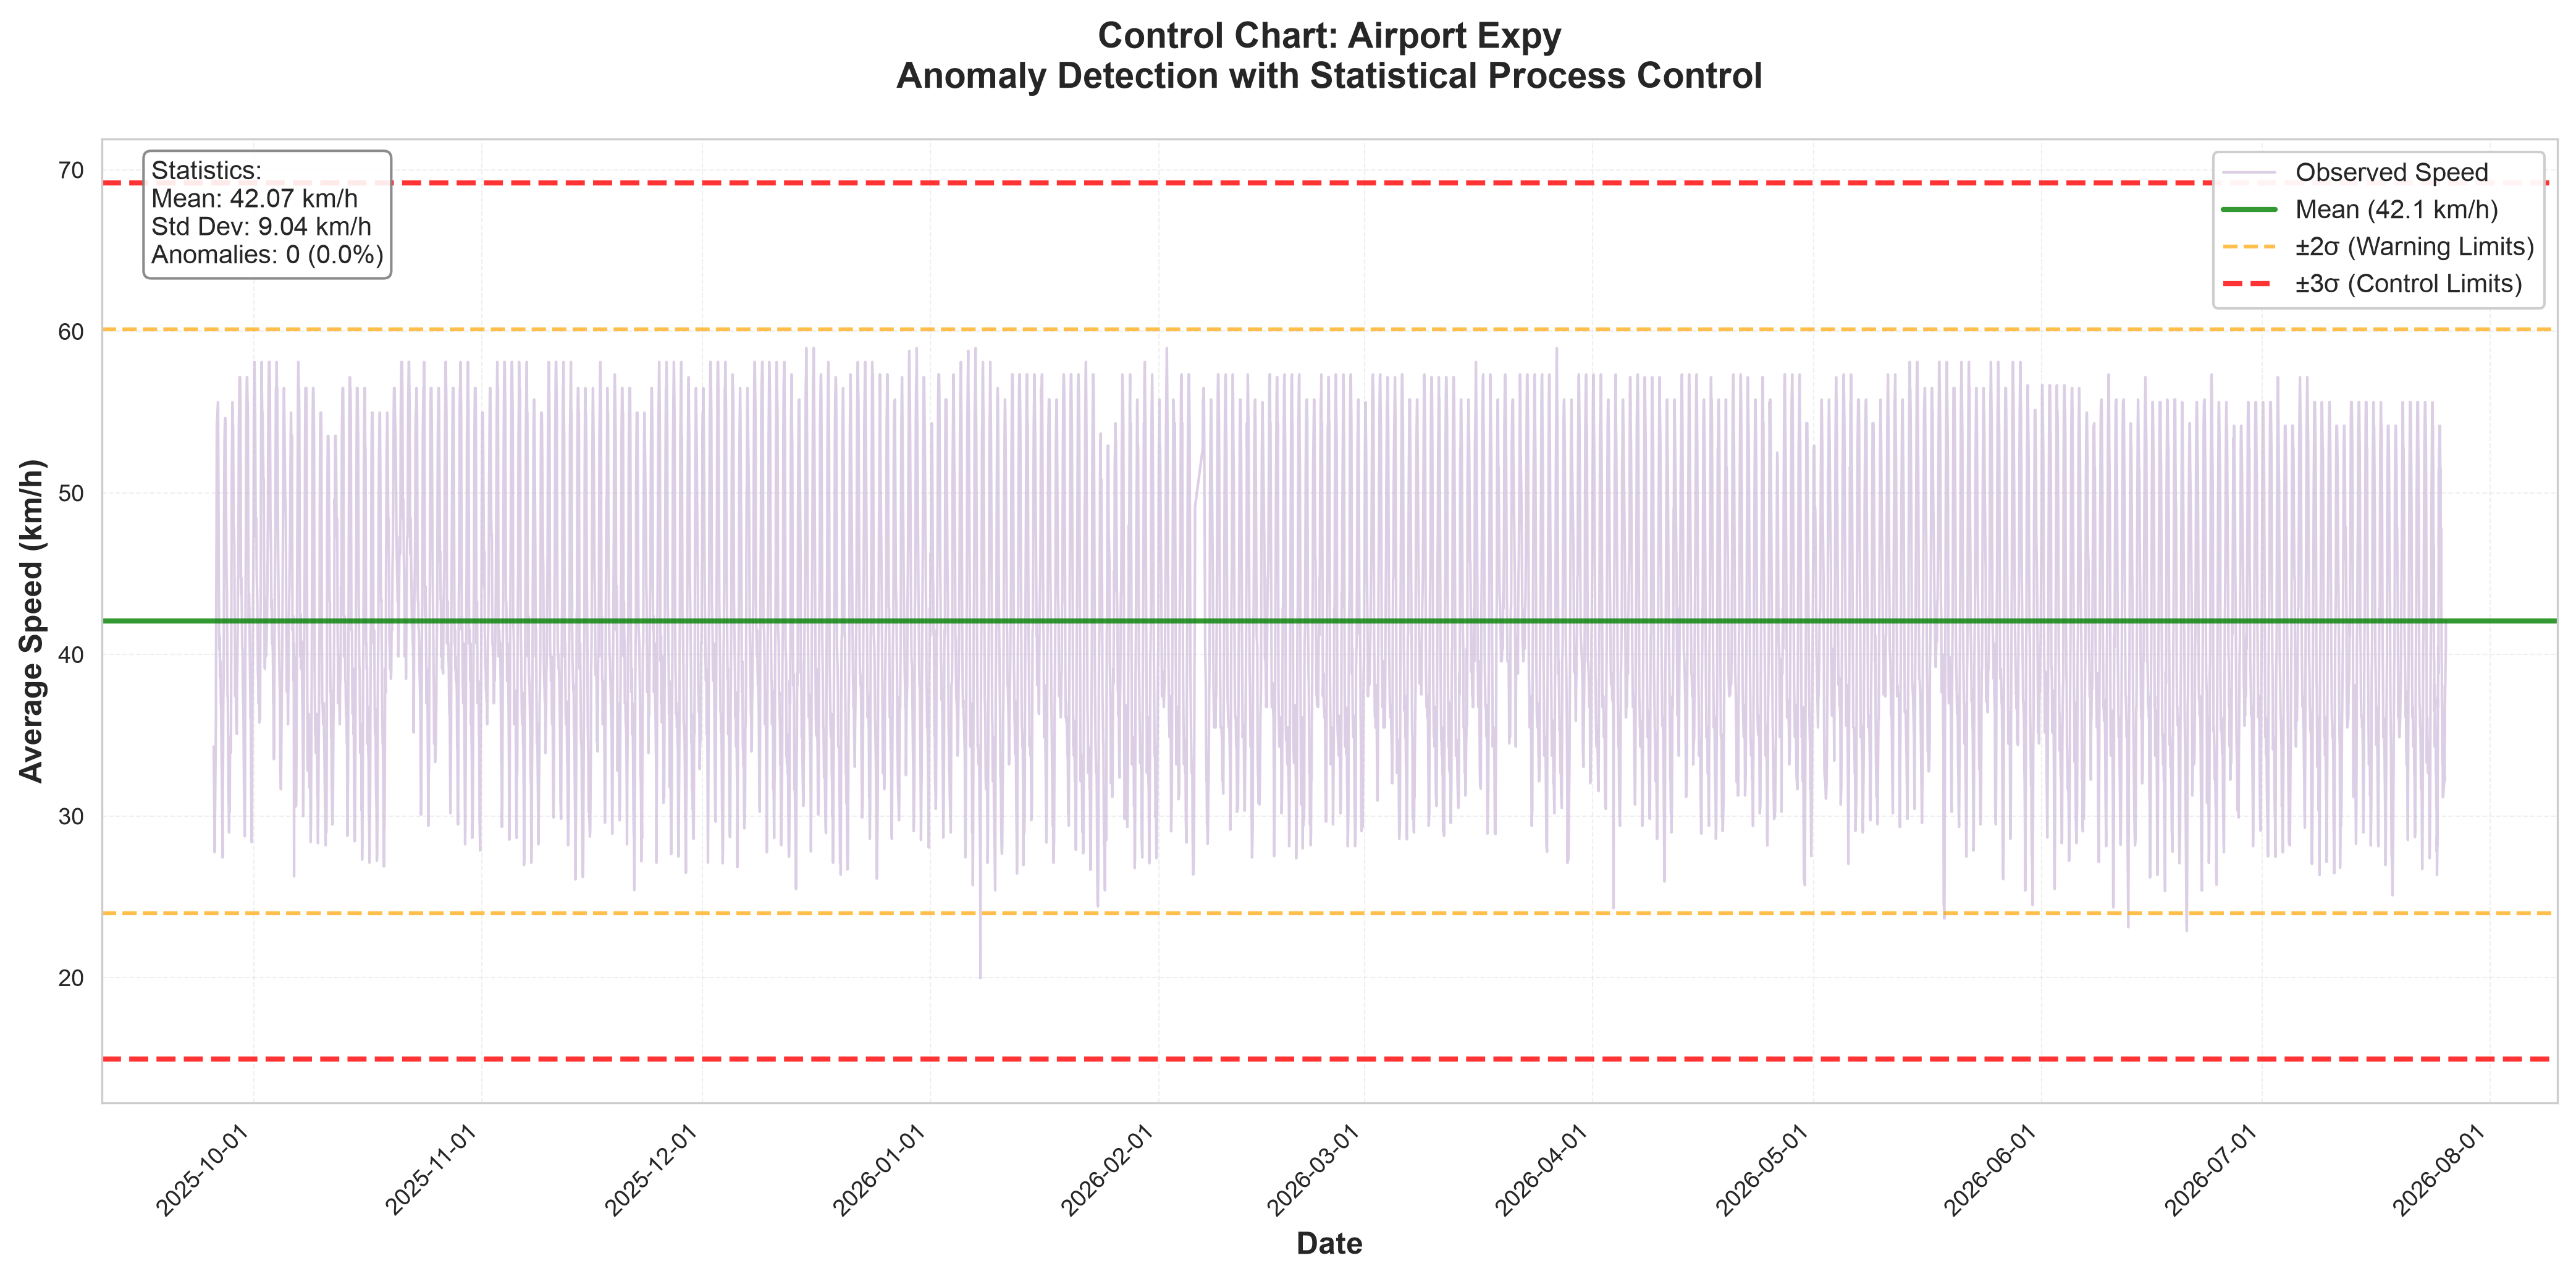

In [19]:
# Pick the top-ranked route from R³S² analysis
example_route = rrs_scores.iloc[0]['route_code']

# Statistical process control chart
viz.plot_control_chart(example_route)

### 5.2 Anomaly Scatter Plot

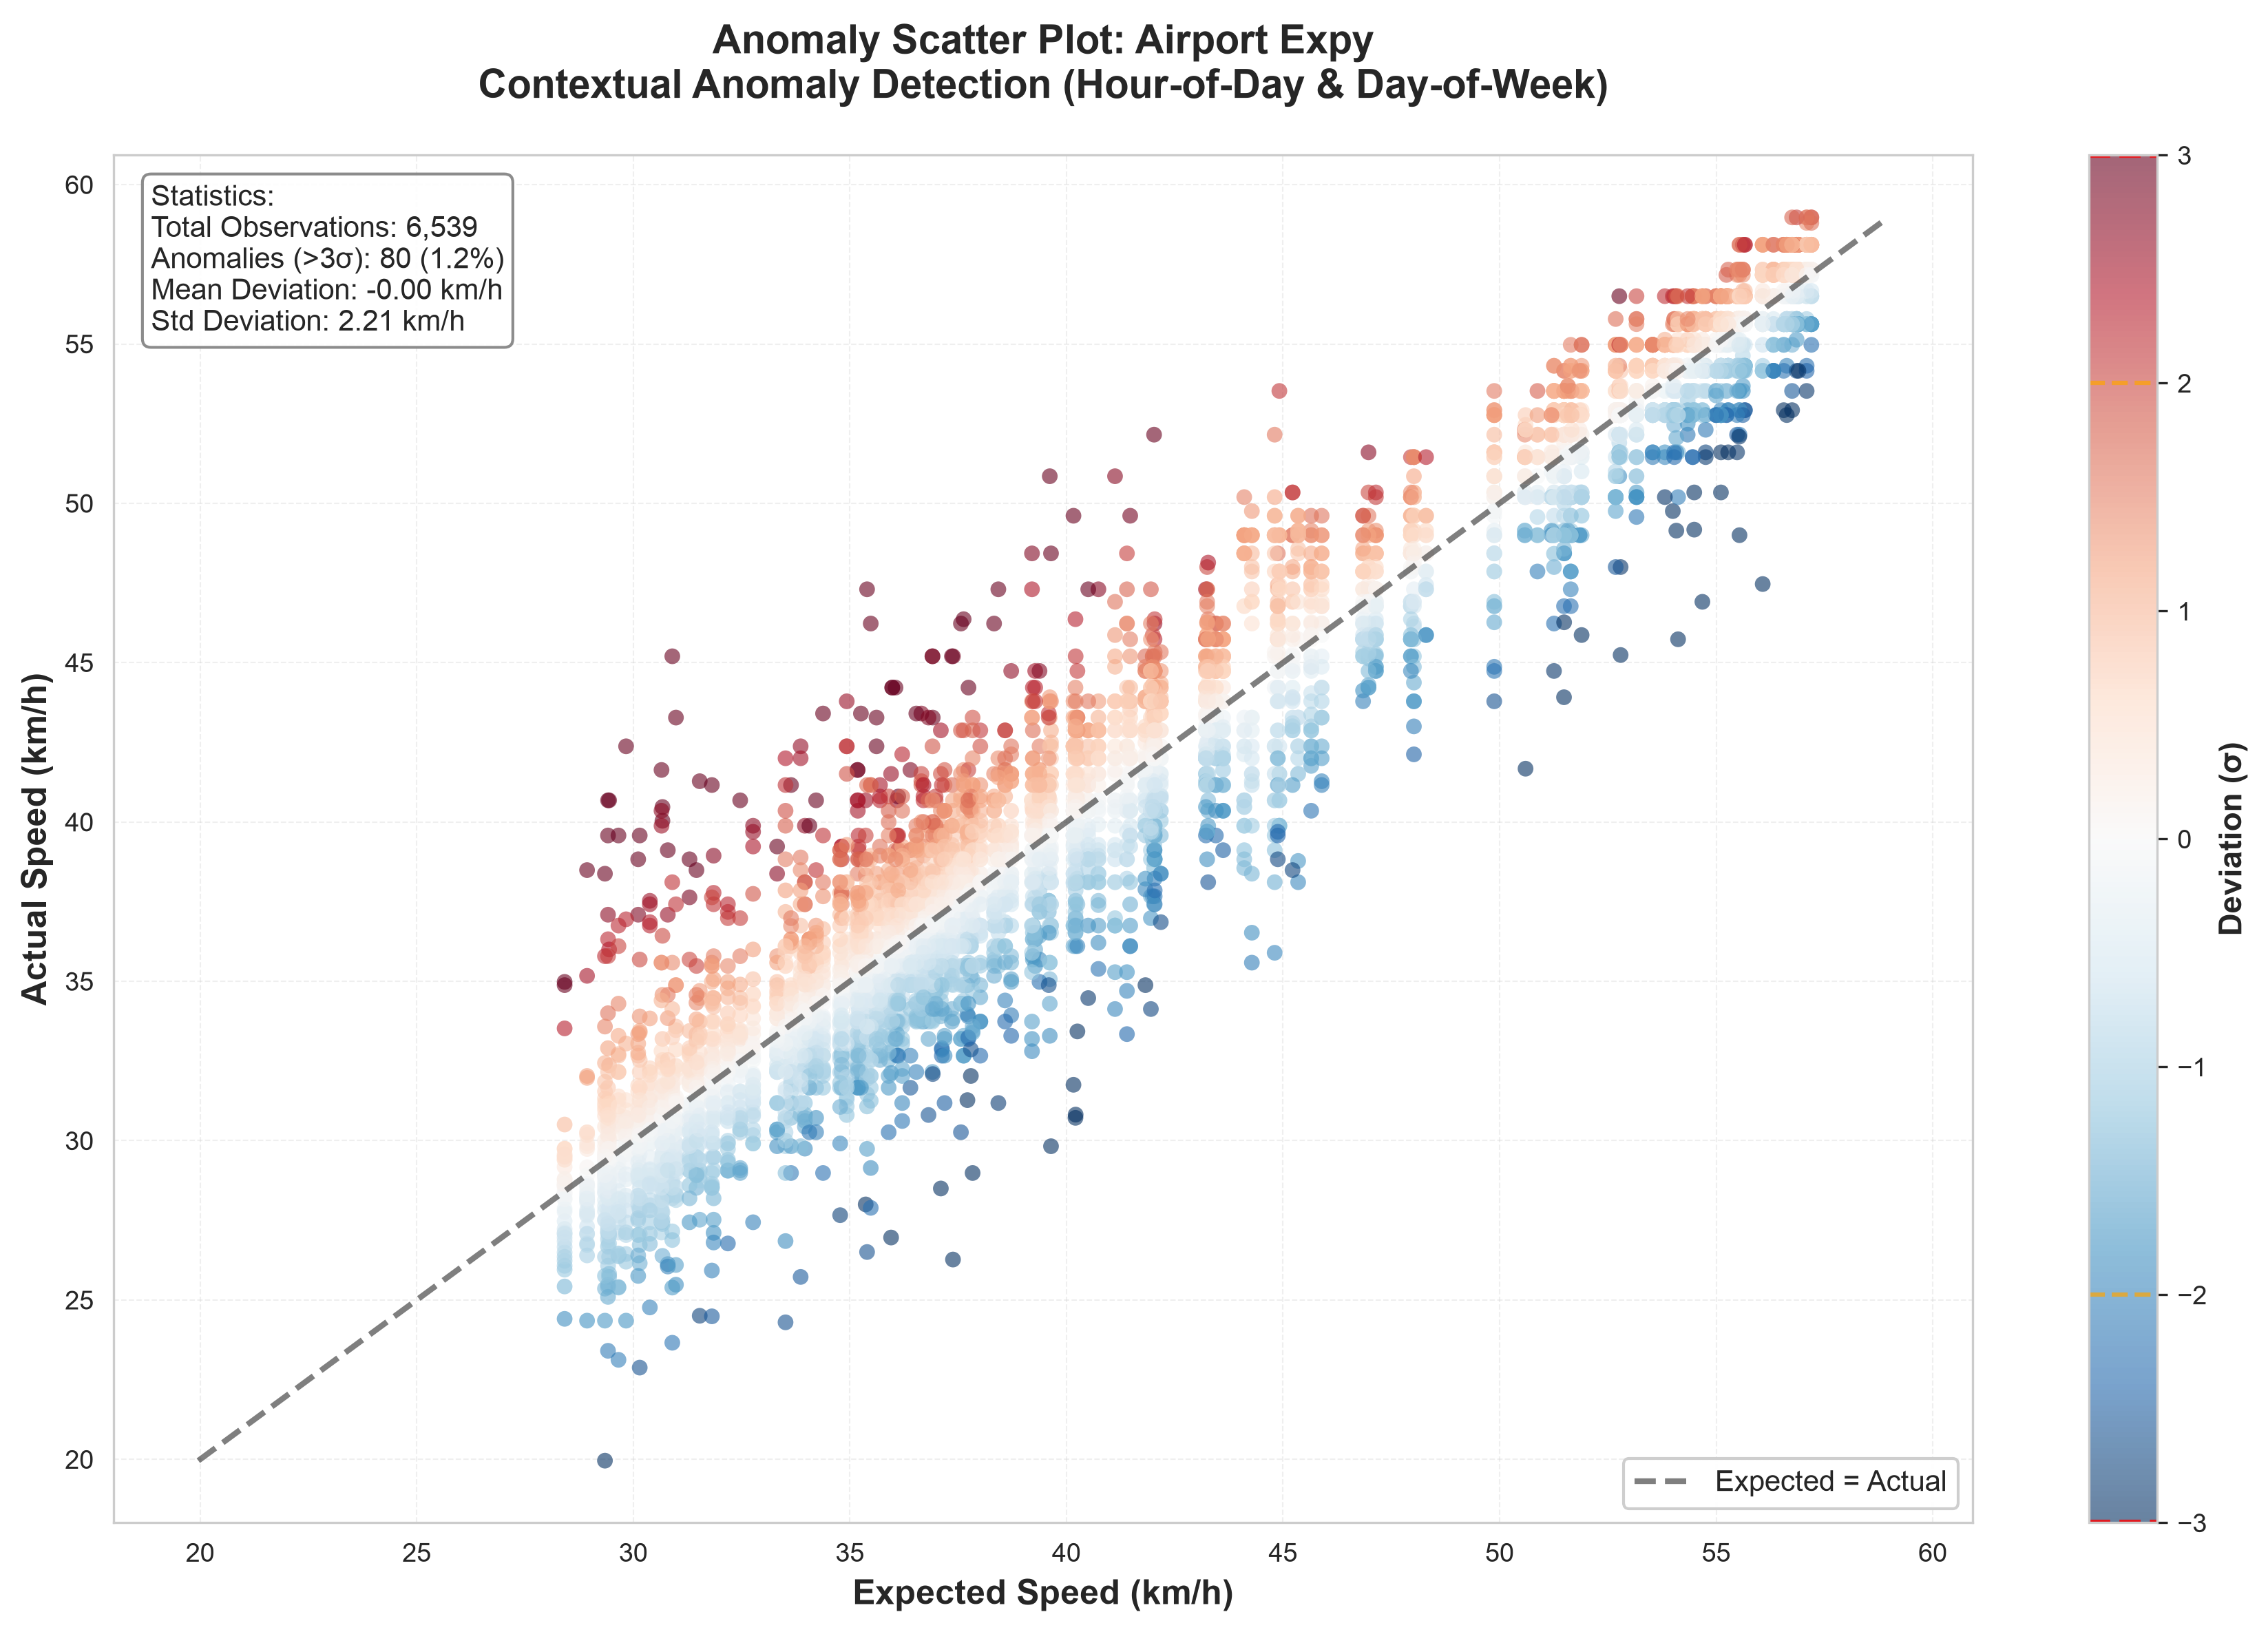

In [20]:
# Contextual anomaly detection
viz.plot_anomaly_scatter(example_route)

### 5.3 Deviation Timeline

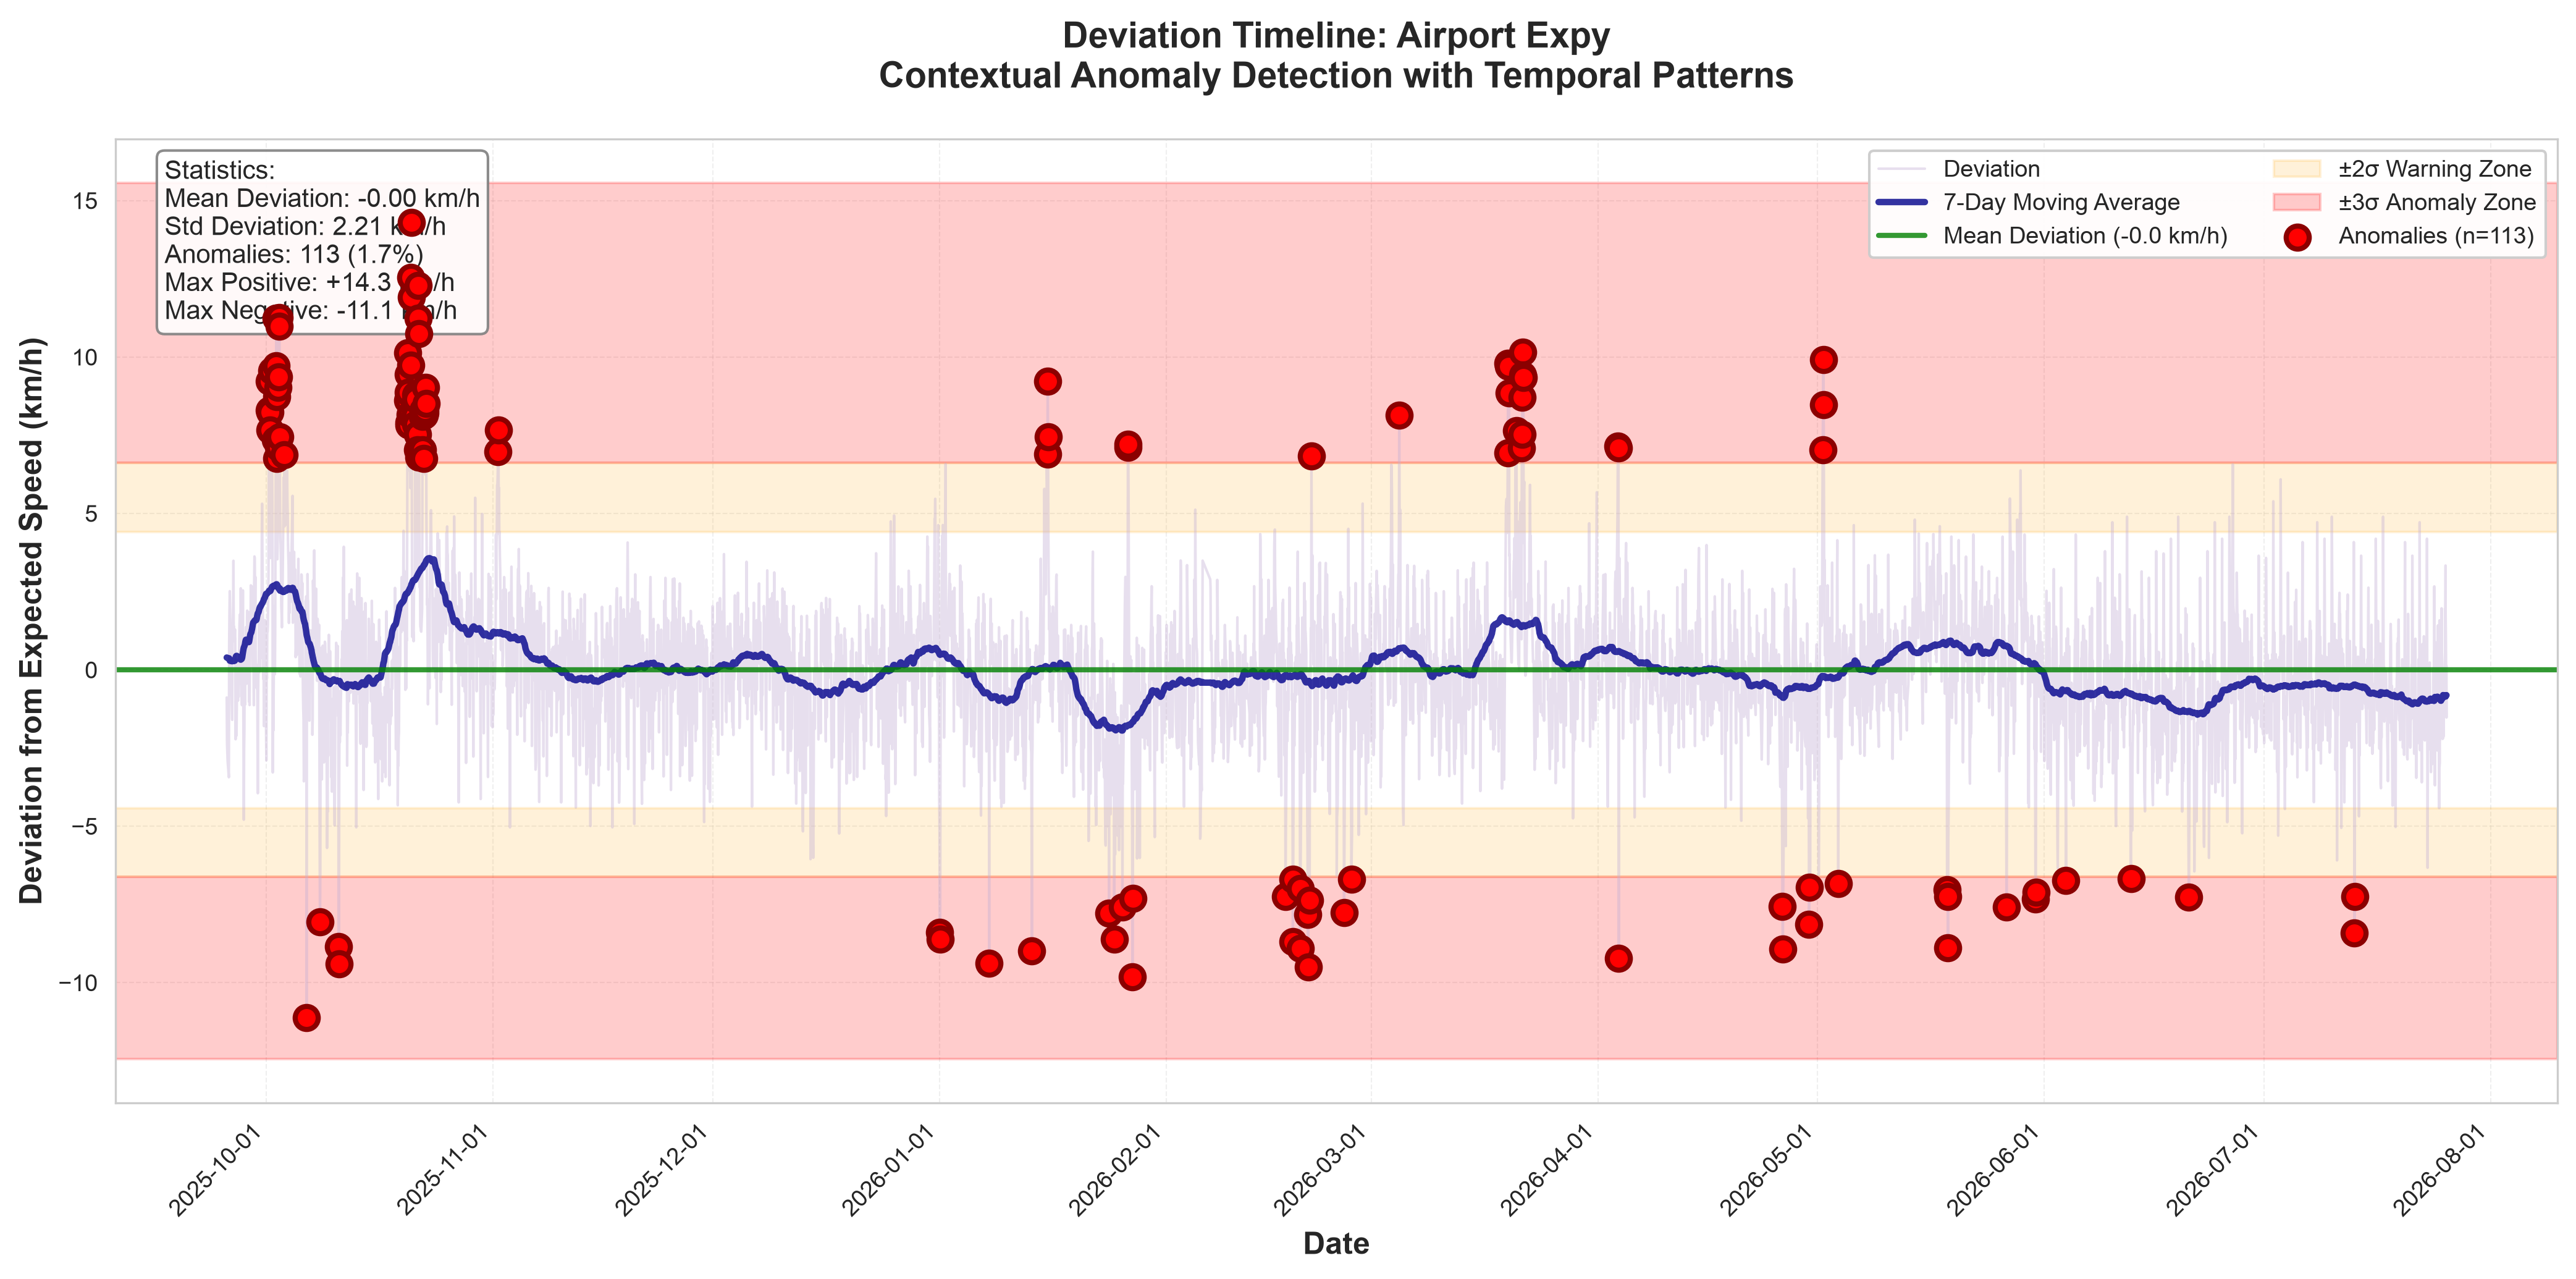

In [21]:
# Timeline of deviations from expected patterns
viz.plot_deviation_timeline(example_route)

### 5.4 Outlier Summary

In [22]:
# Get top anomalous observations
outliers = viz.generate_outlier_summary(top_n=20)
print("Top 20 Anomalous Observations:")
display(outliers)

Top 20 Anomalous Observations:


,timestamp,route_code,route_label,hour,day_of_week,avg_speed,expected_speed,deviation,deviation_sigma
0,2026-07-06 19:00:00,XG48+2W|VHWC+C3,South Outer Ring,19,Monday,27.907,15.221,12.686,5.603
1,2026-01-01 01:00:00,XHJ7+MG|WJM6+VC,Central Diagonal 1,1,Thursday,21.000,35.140,-14.140,-5.475
2,2026-01-01 01:00:00,WH5F+26|WJ8X+F5W,Double Decker Flyover,1,Thursday,22.000,39.027,-17.027,-5.285
3,2026-06-01 00:00:00,WGG8+G5|XH7P+G6,Mysore Road,0,Monday,19.800,31.941,-12.141,-5.266
4,2026-06-01 01:00:00,WGG8+G5|XH7P+G6,Mysore Road,1,Monday,22.000,34.187,-12.187,-5.140
5,2026-01-24 04:00:00,XJG4+7J|5PX4+HQ,Airport Expy,4,Saturday,46.909,54.682,-7.773,-5.138
6,2026-06-20 01:00:00,WGG8+G5|XH7P+G6,Mysore Road,1,Saturday,25.826,33.647,-7.821,-5.125
7,2026-06-01 02:00:00,WGG8+G5|XH7P+G6,Mysore Road,2,Monday,25.826,35.108,-9.282,-5.124
8,2025-10-21 23:00:00,WGG8+G5|XH7P+G6,Mysore Road,23,Tuesday,20.129,30.291,-10.162,-5.091
9,2026-01-01 02:00:00,XJG4+7J|5PX4+HQ,Airport Expy,2,Thursday,47.467,56.074,-8.608,-5.054


## 6. Predictive Insights

### 6.1 Speed Forecast

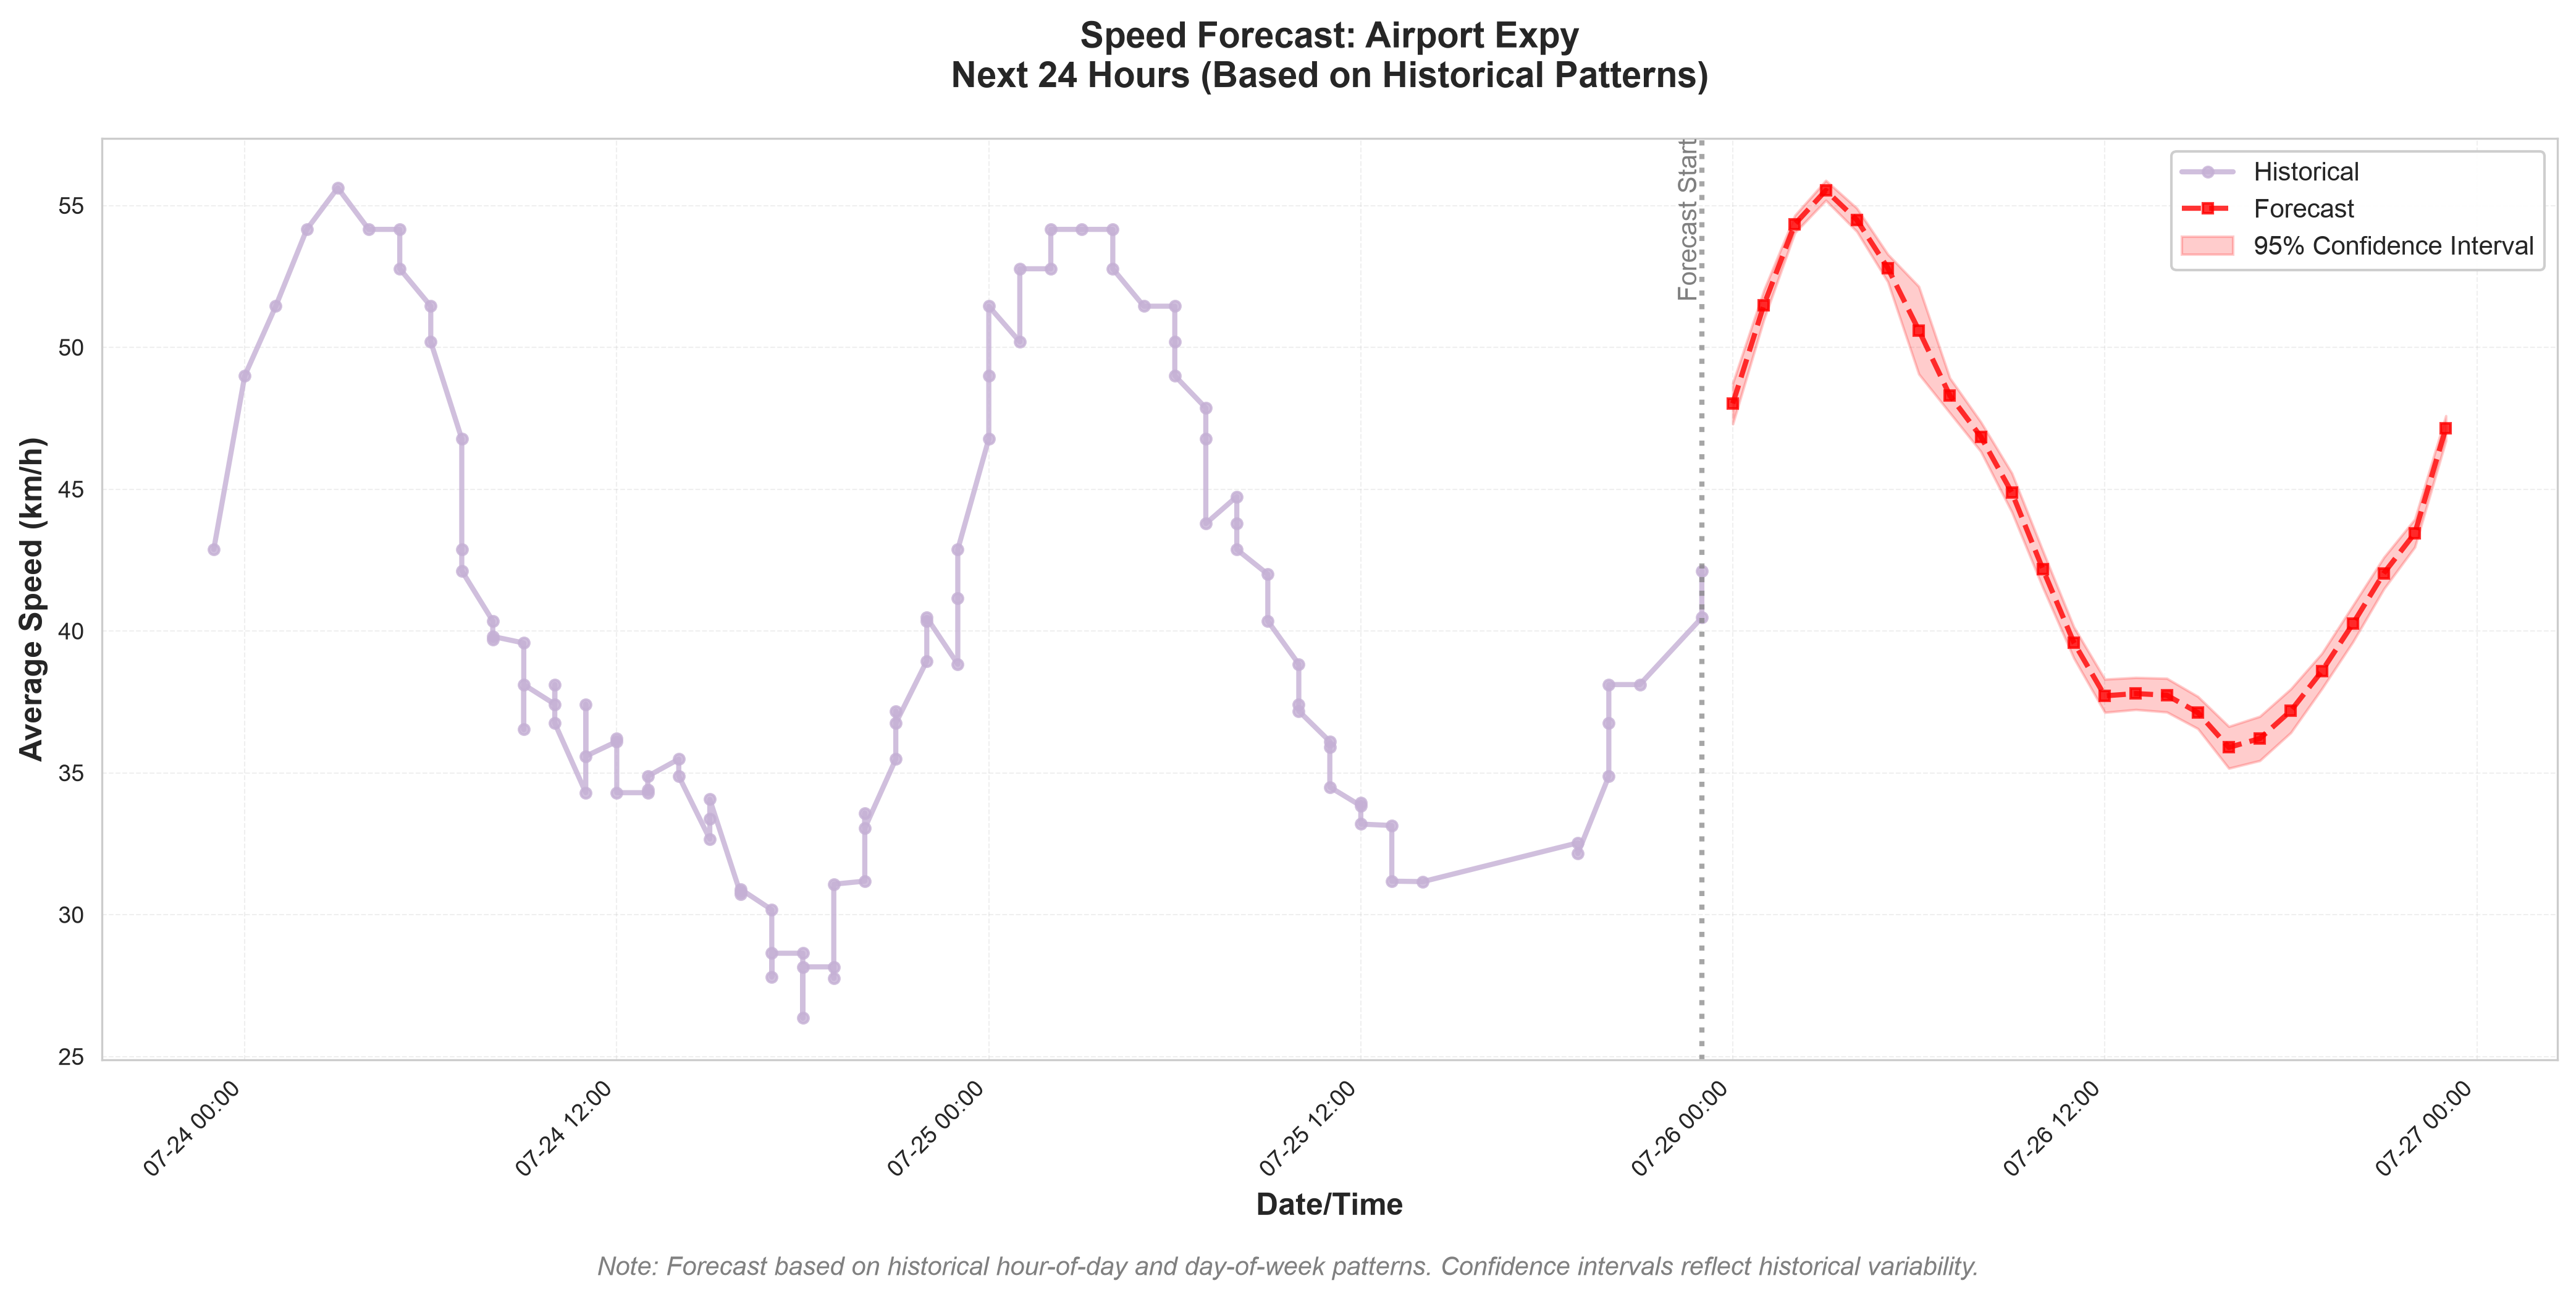

In [23]:
# Forecast next 24 hours
viz.plot_forecast(example_route, forecast_hours=24)

### 6.2 Typical Day Profile

In [ ]:
selector = viz.create_route_checkbox_grid()

def plot_fn(selected_routes):
    if not selected_routes:
        pass
    else:
        viz.plot_typical_day_profile(route_codes=selected_routes)

selector['render'](plot_fn)
display(selector['output'], selector['controls'], selector['grid'])

Output()

GridBox(children=(HBox(children=(HTML(value='<div style="width:14px;height:14px;background-color:#1f77b4;borde…

### 6.3 Best Travel Times

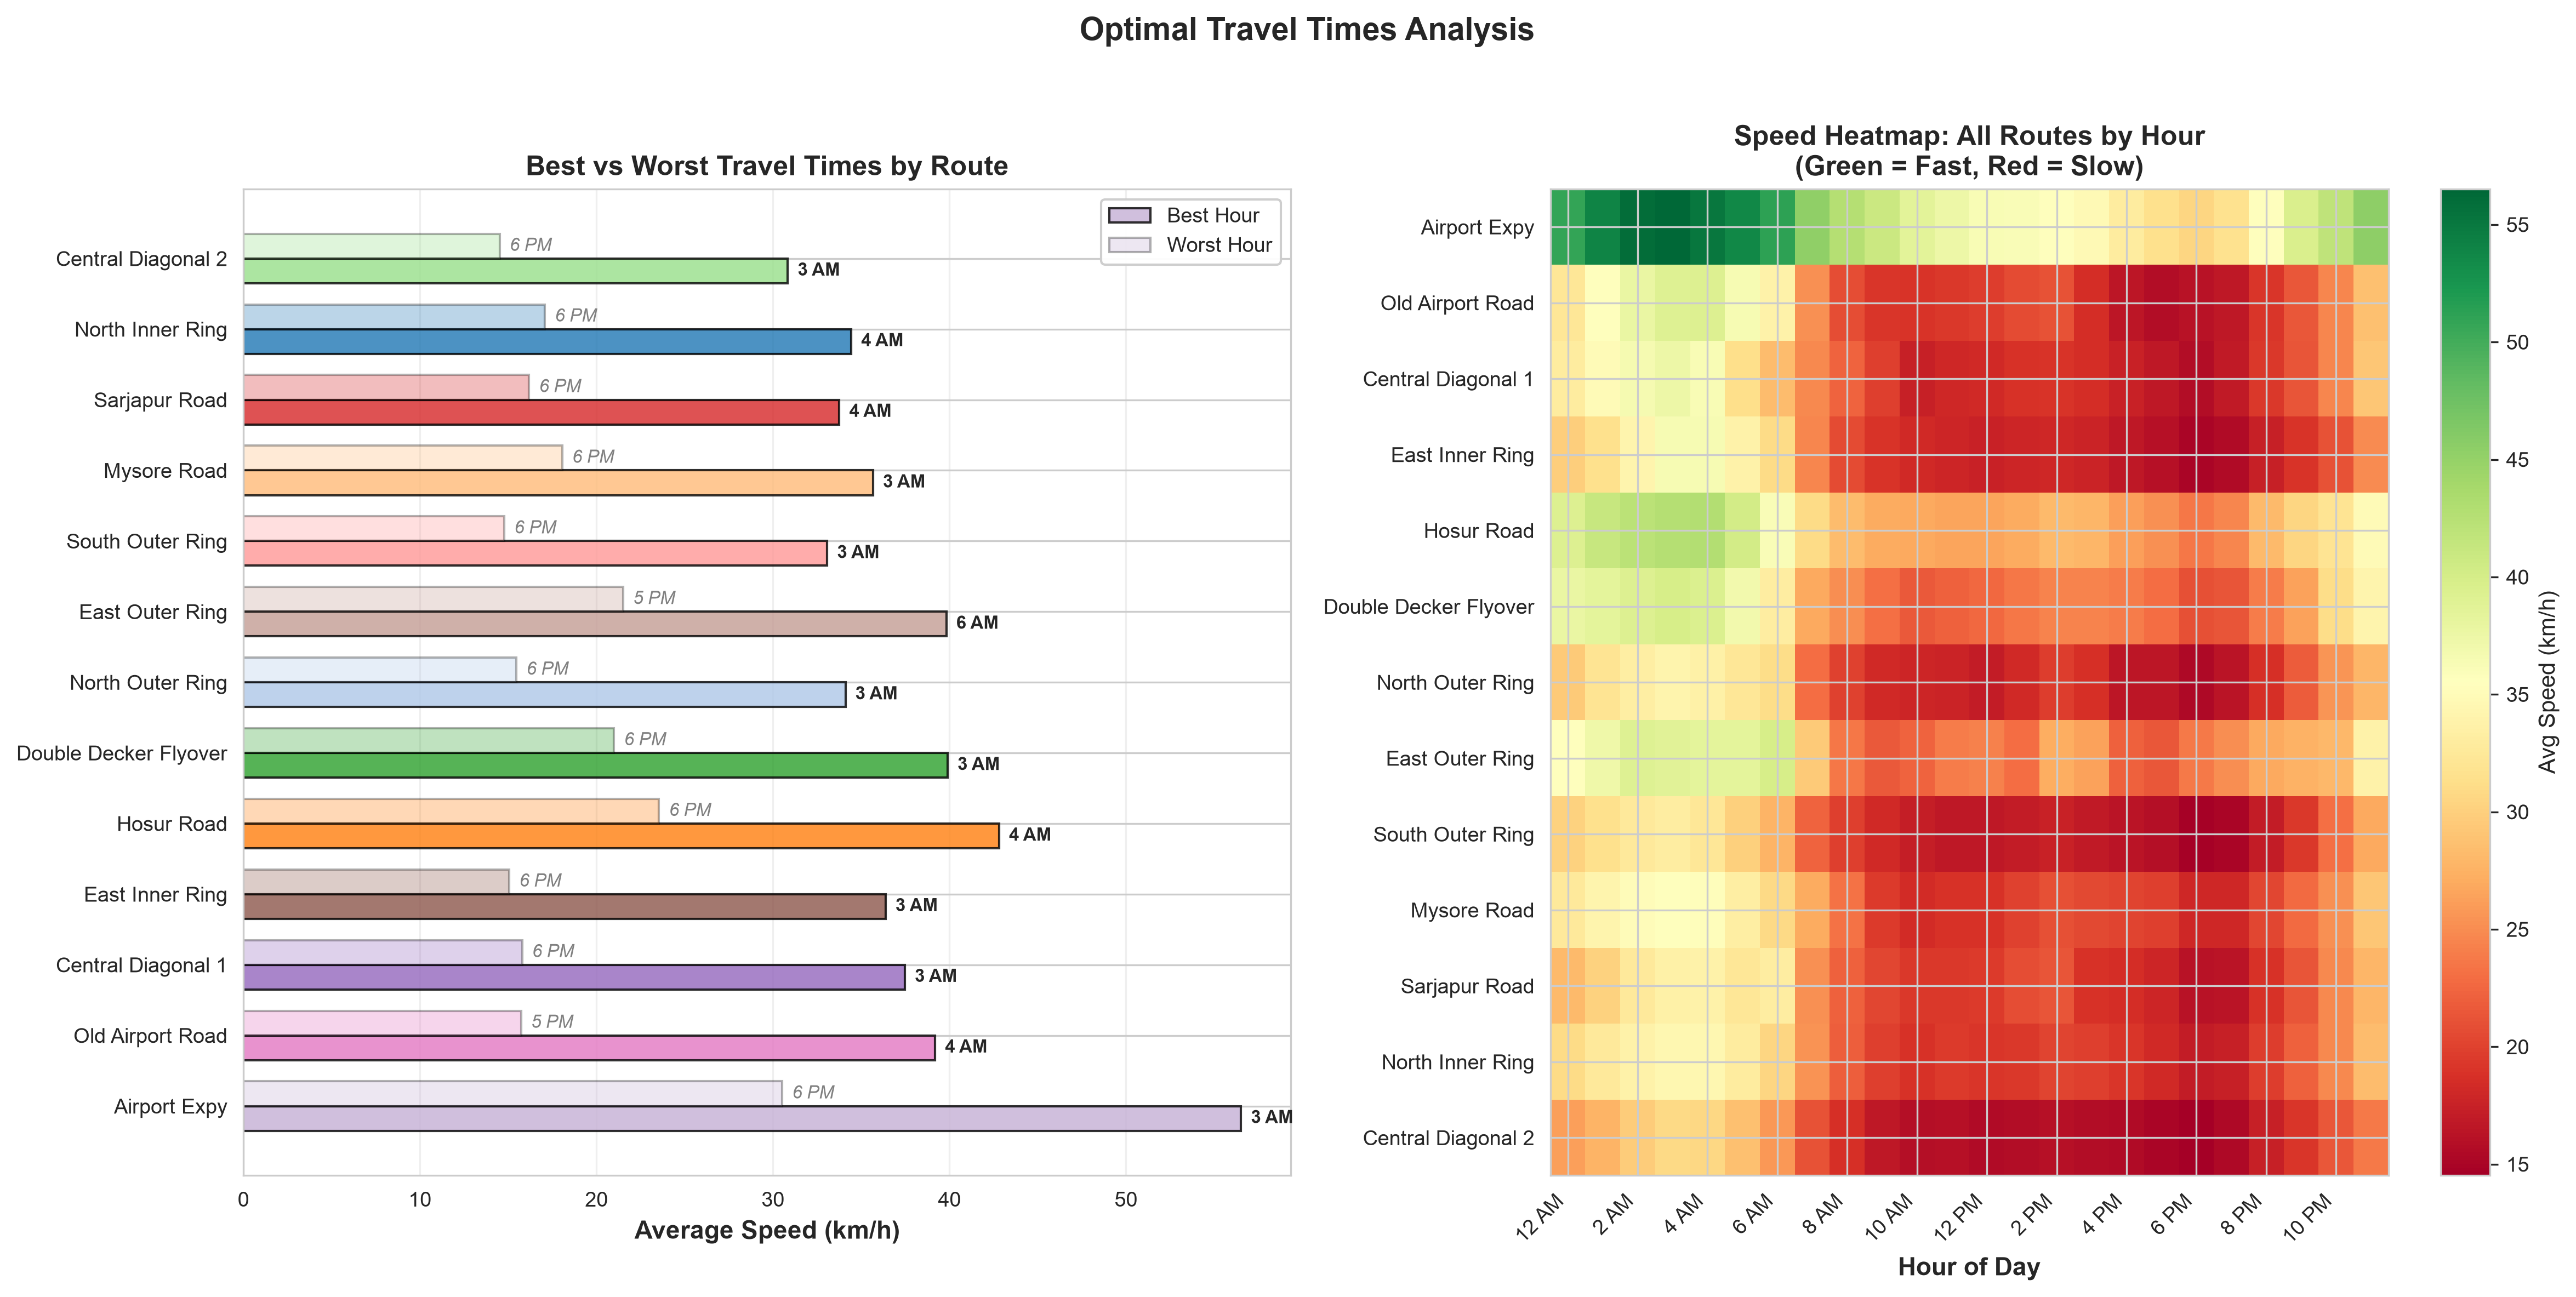


Best Travel Times Summary:
Route                     Best Time       Speed        Worst Time      Speed       
Airport Expy              3 AM              56.5 km/h   6 PM              30.5 km/h
Old Airport Road          4 AM              39.2 km/h   5 PM              15.7 km/h
Central Diagonal 1        3 AM              37.5 km/h   6 PM              15.8 km/h
East Inner Ring           3 AM              36.4 km/h   6 PM              15.1 km/h
Hosur Road                4 AM              42.8 km/h   6 PM              23.5 km/h
Double Decker Flyover     3 AM              39.9 km/h   6 PM              21.0 km/h
North Outer Ring          3 AM              34.1 km/h   6 PM              15.5 km/h
East Outer Ring           6 AM              39.8 km/h   5 PM              21.5 km/h
South Outer Ring          3 AM              33.1 km/h   6 PM              14.8 km/h
Mysore Road               3 AM              35.7 km/h   6 PM              18.1 km/h
Sarjapur Road             4 AM              33.8

In [26]:
# Identify optimal departure times
viz.plot_best_travel_times()

## 7. Interactive Dashboard Components

### 7.2 Interactive Linked Plots (Plotly)

In [30]:
# Create interactive linked plots with hover tooltips
fig = viz.create_linked_plots(route_codes=traffic_df['route_code'].unique()[:3])
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 8. Export Report

In [ ]:
# Export comprehensive HTML report
report_path = viz.export_report_template(
    'traffic_analysis_report.html',
    route_codes=traffic_df['route_code'].unique()[:5],
    include_visualizations=True
)
print(f"Report exported to: {report_path}")

## 9. Alternative Scoring Methods

In [ ]:
# Compare different scoring methods
comparison = analyzer.compare_scoring_methods()

print("Scoring Method Comparison:")
if isinstance(comparison, dict):
    corr_matrix = comparison.get('correlation_matrix')
    stability_metrics = comparison.get('stability')
else:
    corr_matrix = comparison
    stability_metrics = None

print("\nCorrelation Matrix:")
print(corr_matrix)

print("\nStability Metrics:")
if stability_metrics is not None:
    print(stability_metrics)
else:
    print("Not provided separately; refer to correlation matrix above.")

## 10. Statistical Tests

In [ ]:
# Test normality
normality_results = analyzer.test_normality()
print("\nNormality Tests:")

if isinstance(normality_results, pd.DataFrame):
    cols = [c for c in ['route_code', 'shapiro_pvalue', 'anderson_statistic'] if c in normality_results.columns]
    print(normality_results[cols].head(3).to_string(index=False))
else:
    for route, result in list(normality_results.items())[:3]:
        print(f"\n{route}:")
        print(f"  Shapiro-Wilk p-value: {result['shapiro_pvalue']:.4f}")
        print(f"  Anderson-Darling statistic: {result['anderson_statistic']:.4f}")

## Conclusion

This notebook demonstrated the key features of the Traffic Analysis Enhancement system:

1. **R³S² Analysis**: Comprehensive evaluation of the scoring methodology
2. **Temporal Patterns**: Understanding traffic patterns over time
3. **Comparative Analysis**: Comparing routes across multiple dimensions
4. **Anomaly Detection**: Identifying unusual traffic conditions
5. **Predictive Insights**: Forecasting and optimal travel time recommendations
6. **Interactive Dashboards**: Dynamic filtering and exploration
7. **Report Generation**: Exportable analysis summaries

For more details, see the documentation in `TRAFFIC_ANALYSIS_README.md`.

## What is Cosine Similarity?

Cosine similarity measures the **angle** between two vectors in multi-dimensional space, not their magnitude. Two routes with similar *patterns* of speed, duration, and congestion will point in the same direction even if one is a longer commute than the other. The formula is:

\[\text{cosine\_similarity}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}\]

It outputs a value between -1 (opposite) and 1 (identical direction), with 0 meaning orthogonal (unrelated). The key intuition: it ignores *how much* and focuses on *in what proportion* — which is perfect for comparing traffic patterns across routes of different lengths.

The traffic dataset lends itself very well to a cosine similarity project — arguably better than most toy datasets because it has multiple numeric dimensions per route and real temporal structure. Here's a full breakdown.

The csv-traffic-bangalore.csv has exactly the right ingredients :

- **Multiple numeric features per route**: duration, distance, avg_speed (derived), temp, humidity, aqi — these become the dimensions of your vector
- **Route identity**: route_code gives you named entities to compare
- **Temporal aggregation**: the time_category feature lets you build a "traffic fingerprint" per route per time-of-day slot

The richest file for this is `rrs-route-day.csv` or `rrs-route-window.csv` , which appear to be pre-aggregated — they'd give you one row per route per time window, making vector construction trivial.

### Concepts

| Concept | How the dataset teaches it |
|---|---|
| Vectors as "profiles" | Each route's aggregated features = a point in N-dimensional space |
| Magnitude vs. direction | Airport Expy (long, fast) vs. MG Road (short, slow) differ in magnitude but may share a rush-hour *pattern* |
| Normalization matters | Without scaling, duration (minutes) dominates aqi (0–500) — you'll see why StandardScaler is necessary |
| Similarity ≠ distance | Two congested routes look "similar" even if one is 5 km and the other 30 km |

The rrs-route-window.csv file (pre-windowed aggregations, ~55 KB)  is the best starting point — it's small enough to inspect fully, already summarized by time window, and avoids the 4 MB main file until you're ready to scale up.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Build a feature vector per route × time_category
#    Aggregate mean duration and mean avg_speed for each route in each time slot
feature_cols = ['duration', 'avg_speed']
route_time_features = (
    traffic_df
    .groupby(['route_code', 'time_category'])[feature_cols]
    .mean()
    .reset_index()
)

# 2. Pivot into a route × features matrix
#    Each row = one route's traffic fingerprint across all time categories
route_feature_matrix = route_time_features.pivot_table(
    index='route_code',
    columns='time_category',
    values=feature_cols
)
# Flatten MultiIndex columns: ('duration', 'morning_rush') → 'duration_morning_rush'
route_feature_matrix.columns = [f'{feat}_{cat}' for feat, cat in route_feature_matrix.columns]

# Drop rows with any NaN (routes missing data for certain time categories)
route_feature_matrix = route_feature_matrix.dropna()

print(f"Feature matrix shape: {route_feature_matrix.shape}")
print(f"Features: {list(route_feature_matrix.columns)}")

# 3. Standardize features before computing cosine similarity
#    Without scaling, duration (minutes) would dominate avg_speed (km/h)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(route_feature_matrix.values)

# 4. Compute pairwise cosine similarity
sim_matrix = cosine_similarity(scaled_features)
sim_df = pd.DataFrame(
    sim_matrix,
    index=route_feature_matrix.index,
    columns=route_feature_matrix.index
)

# Map route_code → friendly label for the heatmap
label_map = routes_df.set_index('route_code')['label_short'].to_dict()
display_labels = [label_map.get(rc, rc) for rc in sim_df.index]
sim_df.index = display_labels
sim_df.columns = display_labels

# 5. Plot the similarity heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Cosine Similarity', 'shrink': 0.8}
)
ax.set_title('Route Similarity Heatmap (Cosine Similarity)\nBased on mean duration & avg_speed per time category',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Interpret: find the most similar route pairs
sim_pairs = (
    sim_df.where(np.triu(np.ones(sim_df.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print("\nMost similar route pairs (top 5):")
for (route_a, route_b), score in sim_pairs.head(5).items():
    print(f"  {route_a} ↔ {route_b}: {score:.3f}")

print("\nLeast similar route pairs (bottom 5):")
for (route_a, route_b), score in sim_pairs.tail(5).items():
    print(f"  {route_a} ↔ {route_b}: {score:.3f}")